In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy.random import multivariate_normal

import parameters as p
import auxiliary_funcs as af 
import collisions_vec as col
import monte_carlo_vec as mc

# no loss cone

tau_o ions = 2123.1766532800625
ZPAR = 233.3333333333333 should match 233.33
ZPERP = 0.03055752047819377


In [2]:
def singlestep_mc(v_current, D_func, A_func, dt):
    D_loc = D_func(v_current)
    A_loc = A_func(v_current)

    # covariant_matrix = 2 * D_loc * dt
    # dv_D = multivariate_normal(mean=v_current, cov=covariant_matrix, check_valid='warn') - v_current 
    std = np.sqrt(2 * np.diag(D_loc) * dt)
    dv_D = std * np.random.standard_normal(size=len(v_current))
    dv_A = A_loc * dt

    v_new = v_current + dv_D + dv_A

    while v_new[0] < 0: 
        v_new[0] = - v_new[0]

    while v_new[1] < -1 or v_new[1] > 1: # bounce by reflection
        if v_new[1] < -1:
            v_new[1] = -2 - v_new[1]    
        elif v_new[1] > 1:
            v_new[1] = 2 - v_new[1]

    return v_new 


def multistep_mc(v_initial, numsteps, D_func, A_func, dt): 
    v_current = v_initial.copy()
    v_store = []
    v_store.append(v_current)

    for i in tqdm(range(numsteps), desc=f"MC steps x = {v_initial[0]}"):
        v_new = singlestep_mc(v_current, D_func, A_func, dt)
        # print(f'step {i} v = {v_new}')
        v_store.append(v_new)
        v_current = v_new

    return np.array(v_store)

# TEST FULL OPERATOR

In [ ]:
# run full with geometric factor and parallel diffusion 
DT = 1e-5
V_INITIAL = np.array([1, 0])
NUMSTEPS = int(1e7) # better at 1e7

result_geom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, D_func=col.D_xxi, A_func=col.A_xxi, dt=DT)

In [ ]:
v_store = np.array(result_geom)

x = v_store[::5000, 0]
y = v_store[::5000, 1]
t = np.arange(len(x))
# colors = t

colors = t * (NUMSTEPS / len(t))

x_values = v_store[:, 0]
xmax = 1
x_line = np.linspace(0, xmax, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=400)

scatter = axs[0].scatter(x, y, c=colors, cmap='plasma', s=20)
axs[0].plot(x, y, color='gray', alpha=0.3)
axs[0].set_xlabel(r'$x$', fontsize=14)
axs[0].set_ylabel(r'$\xi$', fontsize=14)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].set_ylim(-1,1)
axs[0].set_xlim(0,xmax)

cbar = fig.colorbar(scatter, ax=axs[0])
ticks = np.arange(0, NUMSTEPS+1, NUMSTEPS/10)
cbar.ax.tick_params(labelsize=10) 
cbar.set_ticks(ticks)
cbar.set_label('Time Step', fontsize=13)

axs[1].hist(x_values, bins=100, density=True, alpha=0.7,
            color='mediumslateblue', edgecolor='black')
# axs[1].plot(x_line,
#             4 / np.sqrt(np.pi) * x_line**2 * np.exp(-x_line**2),
#             color='red')
axs[1].set_xlabel(r'$x$', fontsize=14)
axs[1].set_ylabel('Probability Density', fontsize=14)
axs[1].set_xlim(0, xmax)

# plt.title('geom, full operator')
plt.tight_layout()
plt.show()

# TEST NO GEOMETRIC CORRECTION

In [10]:
DT = 1e-5
V_INITIAL = [1, 0]
NUMSTEPS = int(1e7)
result_nogeom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, D_func=col.D_xxi, A_func=col.A_nogeom, dt=DT)

MC steps x = 1: 100%|██████████| 10000000/10000000 [09:50<00:00, 16936.38it/s]


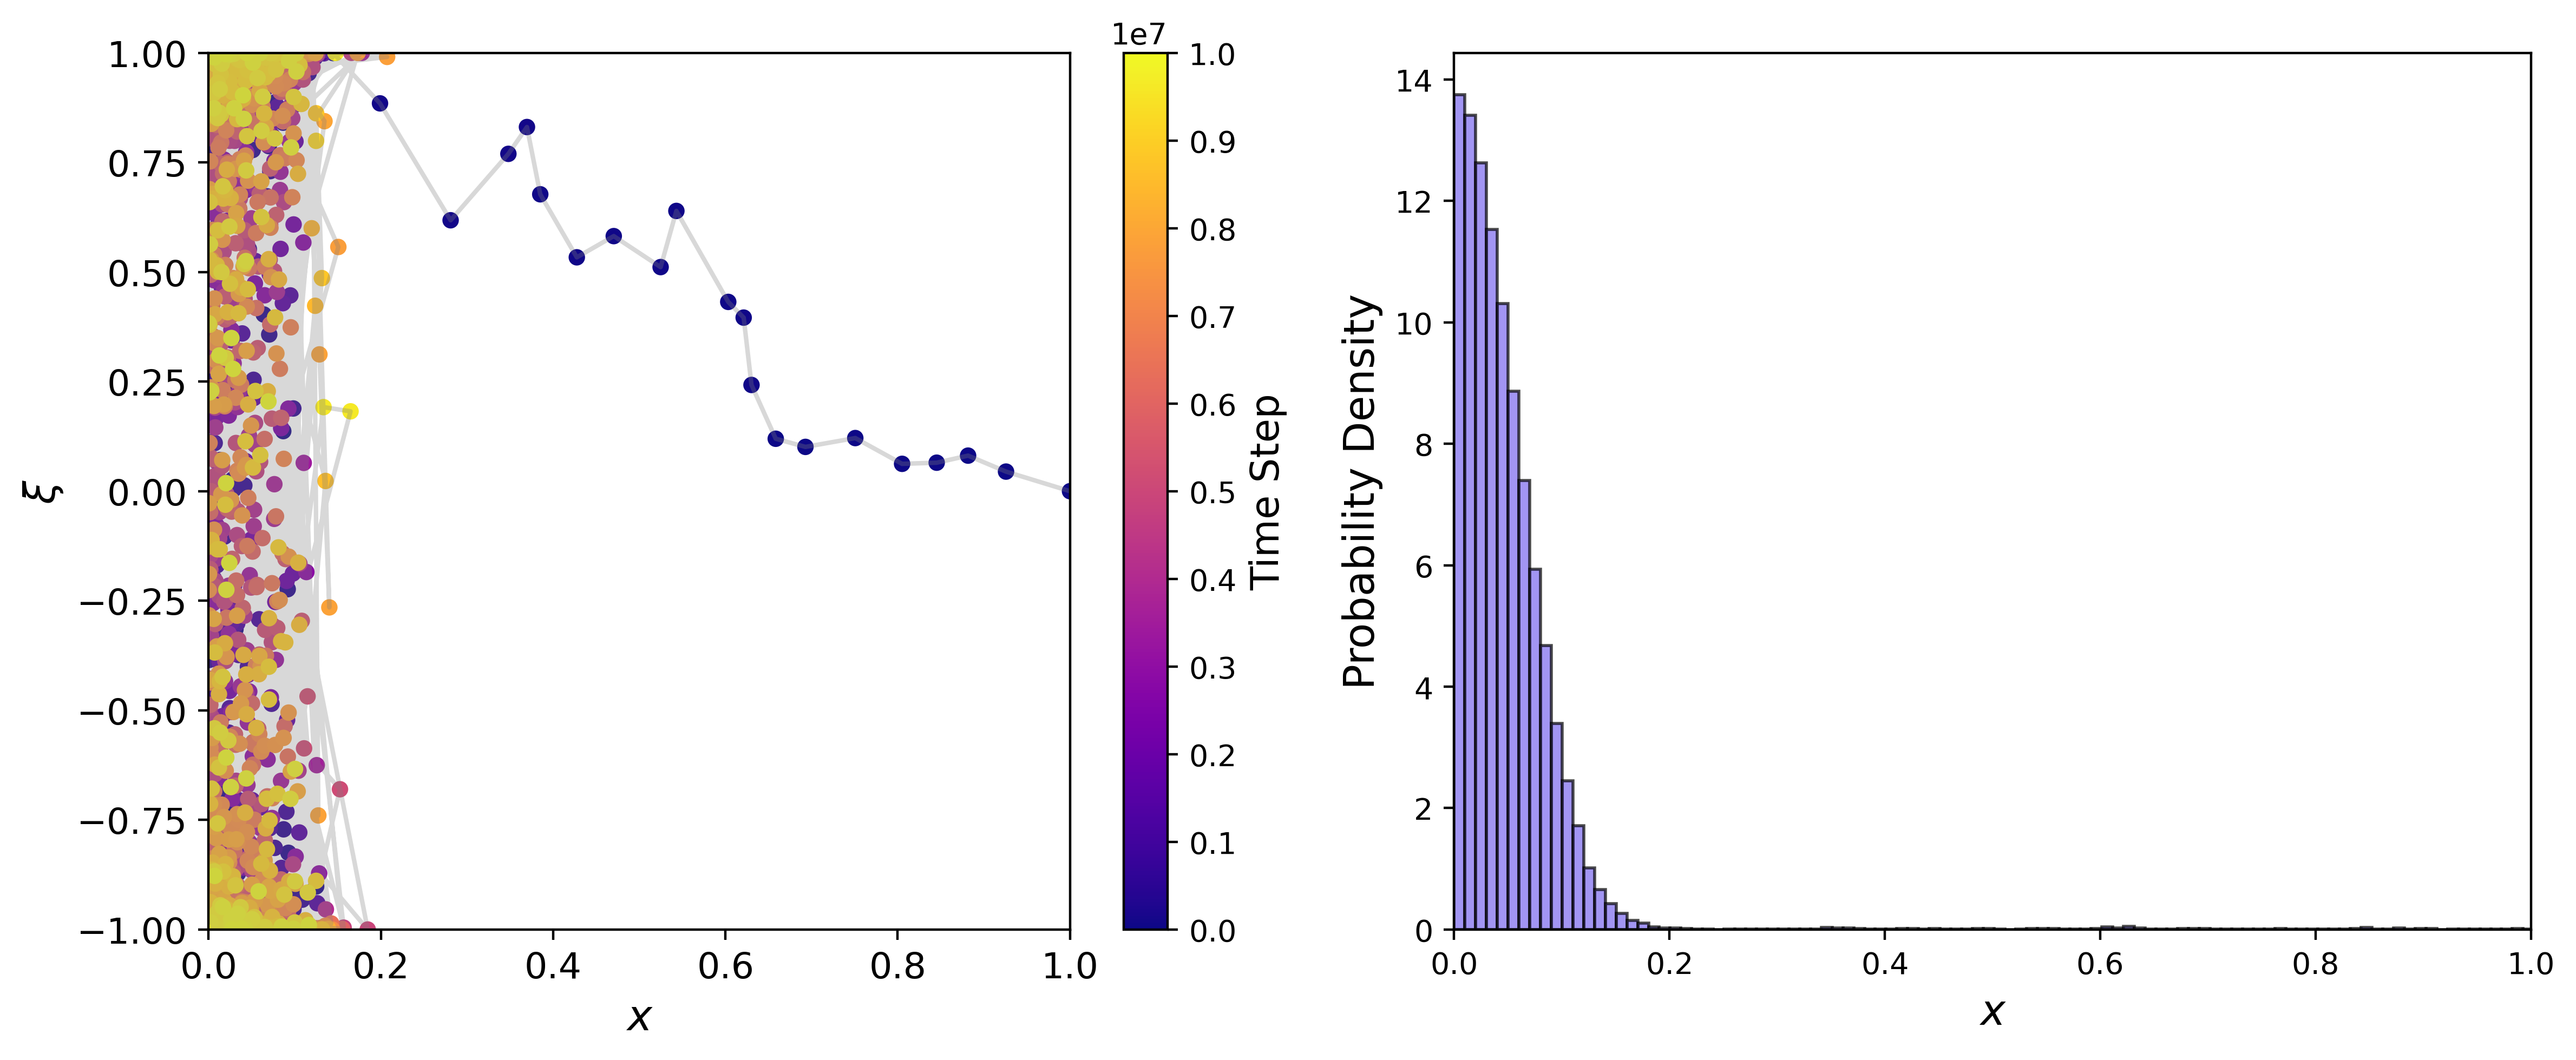

In [19]:
v_store = np.array(result_nogeom)

x = v_store[::5000, 0]
y = v_store[::5000, 1]
t = np.arange(len(x))
# colors = t
colors = t * (NUMSTEPS / len(t))

x_values = v_store[:, 0]
xmax = 1
x_line = np.linspace(0, xmax, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=400)

scatter = axs[0].scatter(x, y, c=colors, cmap='plasma', s=20)
axs[0].plot(x, y, color='gray', alpha=0.3)
axs[0].set_xlabel(r'$x$', fontsize=14)
axs[0].set_ylabel(r'$\xi$', fontsize=14)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].set_ylim(-1,1)
axs[0].set_xlim(0,xmax)

cbar = fig.colorbar(scatter, ax=axs[0])
ticks = np.arange(0, NUMSTEPS+1, NUMSTEPS/10)
cbar.ax.tick_params(labelsize=10) 
cbar.set_ticks(ticks)
cbar.set_label('Time Step', fontsize=13)

axs[1].hist(x_values, bins=100, density=True, alpha=0.7,
            color='mediumslateblue', edgecolor='black')
axs[1].set_xlabel(r'$x$', fontsize=14)
axs[1].set_ylabel('Probability Density', fontsize=14)
axs[1].set_xlim(0, xmax)

# plt.title('no geom')
plt.tight_layout()
plt.show()

# TEST NO PARALLEL CASE WITH GEOMETRICAL CORRECTION

In [60]:
DT = 1e-5
V_INITIAL = [1, 0]
NUMSTEPS = int(1.2e5)
result_nopar = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, D_func=col.D_nopar, A_func=col.A_nopar, dt=DT)
# just gets advected straight to zero. 


MC steps x = 1: 100%|██████████| 120000/120000 [00:20<00:00, 5961.67it/s] 


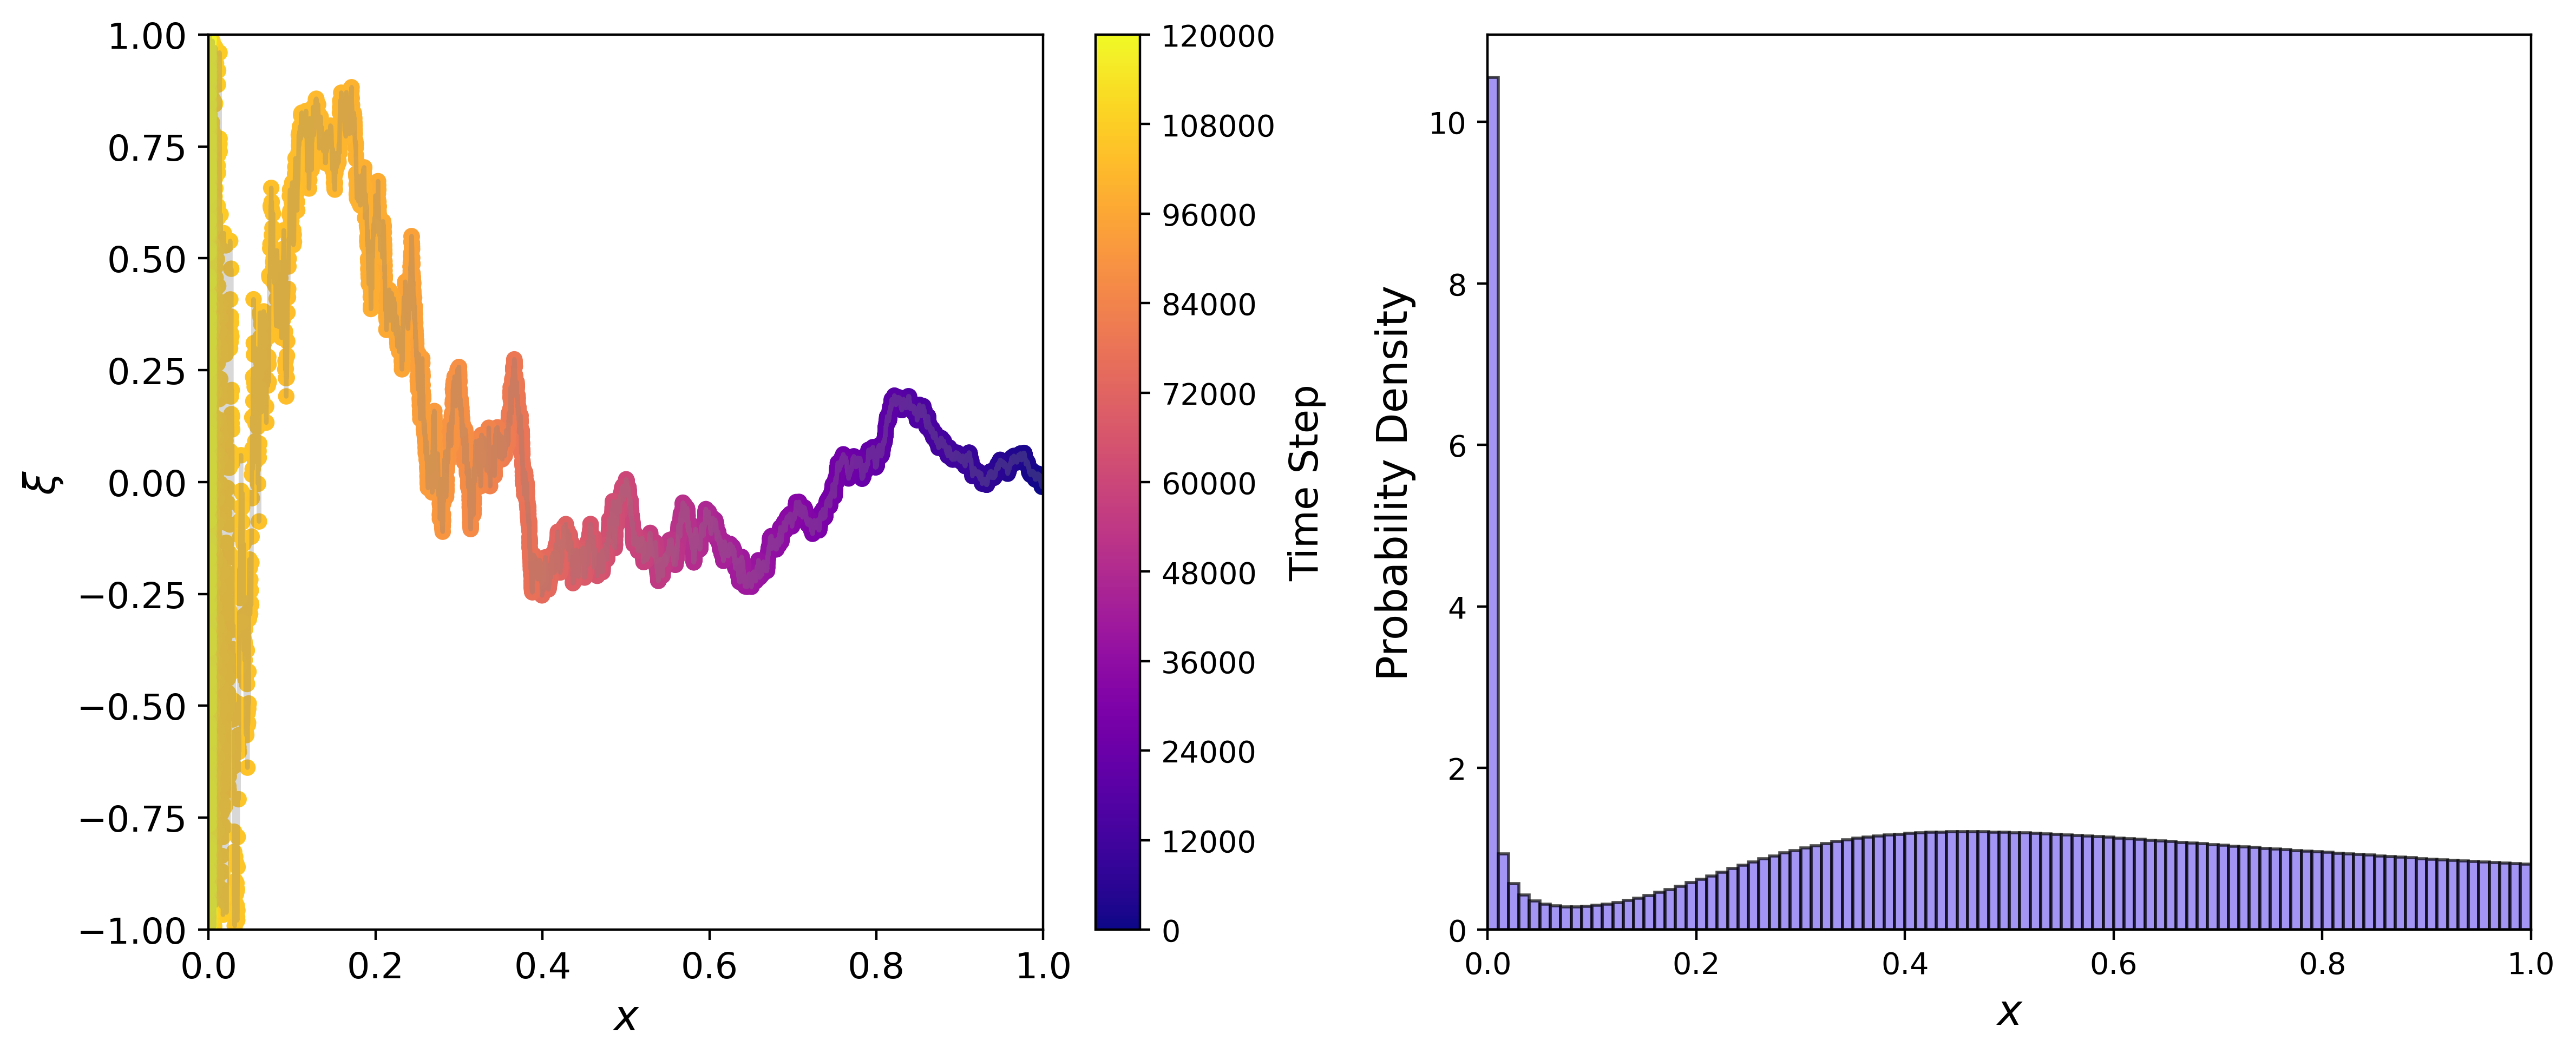

In [61]:
v_store = np.array(result_nopar)

x = v_store[::10, 0]
y = v_store[::10, 1]
t = np.arange(len(x))
colors = t * (NUMSTEPS / len(t))

x_values = v_store[:, 0]
xmax = 1
x_line = np.linspace(0, xmax, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=400)

scatter = axs[0].scatter(x, y, c=colors, cmap='plasma', s=20)
axs[0].plot(x, y, color='gray', alpha=0.3)
axs[0].set_xlabel(r'$x$', fontsize=14)
axs[0].set_ylabel(r'$\xi$', fontsize=14)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].set_xlim(0, 1)
axs[0].set_ylim(-1, 1)

cbar = fig.colorbar(scatter, ax=axs[0])
ticks = np.arange(0, NUMSTEPS+1, NUMSTEPS/10)
cbar.ax.tick_params(labelsize=10) 
cbar.set_ticks(ticks)
cbar.set_label('Time Step', fontsize=13)

axs[1].hist(x_values, bins=100, density=True, alpha=0.7,
            color='mediumslateblue', edgecolor='black')
axs[1].set_xlabel(r'$x$', fontsize=14)
axs[1].set_ylabel('Probability Density', fontsize=14)
axs[1].set_xlim(0, xmax)

plt.tight_layout()
plt.show()

# TEST NO PARALLEL CASE WITHOUT GEOMETRIC CORRECTION - MESA DAME

In [ ]:
DT = 1e-5
V_INITIAL = [10, 0]
NUMSTEPS = int(4.8e5)
result_mesa = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, D_func=col.D_nopar, A_func=col.A_mesa, dt=DT)

MC steps x = 10: 100%|██████████| 480000/480000 [00:32<00:00, 14638.96it/s]


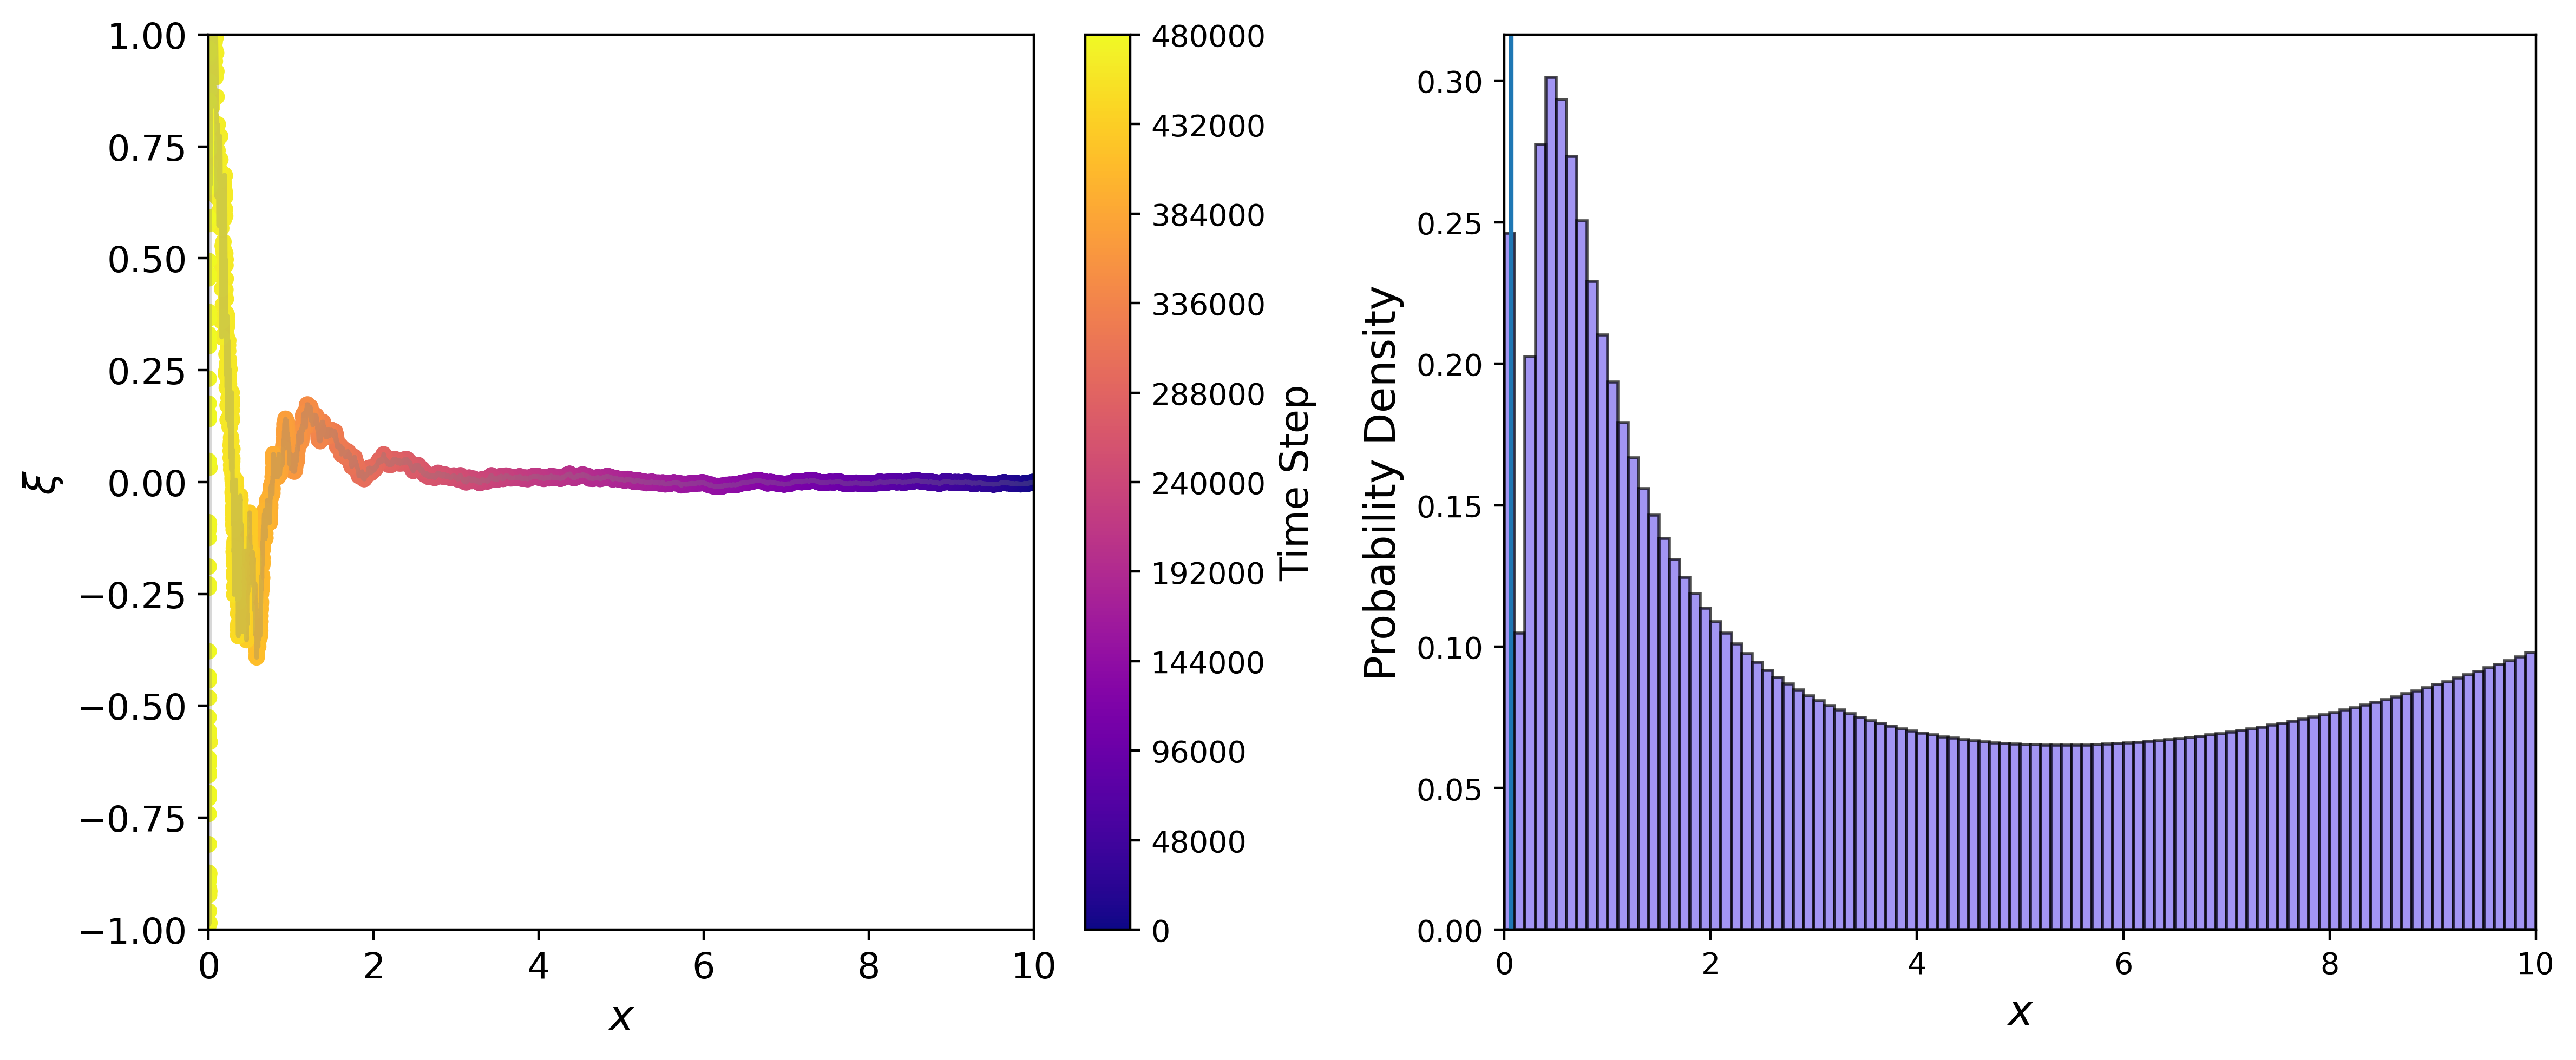

In [ ]:
v_store = np.array(result_mesa)

x = v_store[::100, 0]
y = v_store[::100, 1]
t = np.arange(len(x))
colors = t * (NUMSTEPS / len(t))

x_values = v_store[:, 0]
xmax = 10
x_line = np.linspace(0, xmax, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=400)

scatter = axs[0].scatter(x, y, c=colors, cmap='plasma', s=20)
axs[0].plot(x, y, color='gray', alpha=0.3)
axs[0].set_xlabel(r'$x$', fontsize=14)
axs[0].set_ylabel(r'$\xi$', fontsize=14)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].set_xlim(0, xmax)
axs[0].set_ylim(-1, 1)

cbar = fig.colorbar(scatter, ax=axs[0])
ticks = np.arange(0, NUMSTEPS+1, NUMSTEPS/10)
cbar.ax.tick_params(labelsize=10) 
cbar.set_ticks(ticks)
cbar.set_label('Time Step', fontsize=13)

axs[1].hist(x_values, bins=100, density=True, alpha=0.7,
            color='mediumslateblue', edgecolor='black')
axs[1].set_xlabel(r'$x$', fontsize=14)
axs[1].set_ylabel('Probability Density', fontsize=14)
axs[1].set_xlim(0, xmax)
axs[1].axvline(0.0655)

plt.tight_layout()
plt.show()